# Preprocessing

## Importing Libraries

In [1]:
! pip install numpy pandas opencv-python scikit-image scikit-learn
! pip install lightgbm



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ─────────────────── Core Libraries ───────────────────
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ─────────────────── Skimage for Preprocessing ───────────────────
from skimage.color import rgb2gray
from skimage import exposure
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

# ─────────────────── Scikit-learn ───────────────────
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_fscore_support
)
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ─────────────────── Boosting ───────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ─────────────────── Distributions for Hyperparameter Search ───────────────────
from scipy.stats import uniform, randint

# ─────────────────── TensorFlow / Keras ───────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## Metadata preprocessing

In [3]:
# Load dataset for inspection
metadata_path = 'HAM10000_metadata.csv'
df = pd.read_csv(metadata_path)

# Display dataset info
print("Dataset Info:")
print(df.info())

# Display first few rows
print("\nFirst 5 Rows:")
print(df.head())

# Display missing values count
print("\nMissing Values:")
print(df.isnull().sum())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display unique values for the diagnosis column (target classes)
print("\nUnique Diagnosis Labels:")
print(df['dx'].unique())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None

First 5 Rows:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

Missing Values

## Preprocessing

In [4]:
IMG_SIZE = (32, 32)
BENIGN_TYPES    = ['df', 'bkl', 'vasc', 'nv']
MALIGNANT_TYPES = ['bcc', 'mel', 'akiec']
LABEL_MAP = {'Benign': 0, 'Malignant': 1}
IMG_DIR = Path(r"C:\Users\LENOVO\OneDrive - Asia Pacific University\Desktop\Assinments APU\sem3\project\Project_AI\HAM10000_images")
df = pd.read_csv("HAM10000_metadata.csv")


In [5]:
# 1.1 Create a “diagnosis_group” column of strings "Benign"/"Malignant"
df['diagnosis_group'] = df['dx'].apply(
    lambda x: 'Benign' if x in BENIGN_TYPES else ('Malignant' if x in MALIGNANT_TYPES else np.nan)
)
df = df.dropna(subset=['diagnosis_group']).reset_index(drop=True)


In [6]:
# 1.2 Split into benign vs malignant
df_benign = df[df['diagnosis_group']=='Benign']
df_malig  = df[df['diagnosis_group']=='Malignant']

df_ben_half = df_benign.sample(frac=0.5, random_state=42)
print("After partial undersampling:", df_ben_half['diagnosis_group'].value_counts().to_dict())


After partial undersampling: {'Benign': 4030}


In [7]:
# 1.4 Oversample malignant to match full benign count
df_mal_upsampled = resample(df_malig,
                            replace=True,
                            n_samples=len(df_benign),
                            random_state=42)
print("After oversampling malignant:", df_mal_upsampled['diagnosis_group'].value_counts().to_dict())


After oversampling malignant: {'Malignant': 8061}


In [8]:
# 1.5 Combine into final balanced dataset
df_bal = pd.concat([df_benign, df_mal_upsampled]).reset_index(drop=True)

In [9]:
# 1.4 Attach full filepaths
all_paths = list(IMG_DIR.rglob("*.jpg"))
id2path = {p.stem: p for p in all_paths}
df_bal['path'] = df_bal['image_id'].map(id2path)
df_bal = df_bal.dropna(subset=['path']).reset_index(drop=True)


In [19]:
# 1.5 Map “Benign”→0, “Malignant”→1
df_bal['label'] = df_bal['diagnosis_group'].map(LABEL_MAP)

print(f"Balanced dataset size: {len(df_bal)}")

Balanced dataset size: 16122


Final class balance (label counts):
label
0    8061
1    8061
Name: count, dtype: int64


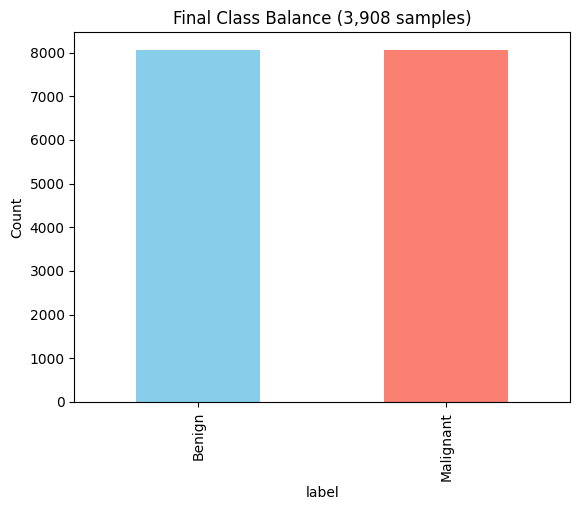

In [11]:
print("Final class balance (label counts):")
print(df_bal['label'].value_counts())


df_bal['label'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title("Final Class Balance (3,908 samples)")
plt.ylabel("Count")
plt.show()


In [12]:
# Data generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1./255
)

In [13]:
# Load original color images
def load_images(indexes):
    images, labels = [], []
    for idx in indexes:
        img_bgr = cv2.imread(df_bal.loc[idx, "path"])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        images.append(img_resized)
        labels.append(df_bal.loc[idx, "label"])
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


In [14]:
# Train/val/test split
train_idx, test_idx = train_test_split(df_bal.index, test_size=0.3, stratify=df_bal['label'], random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=df_bal.loc[train_idx, 'label'], random_state=42)
X_train, y_train = load_images(train_idx)
X_val, y_val = load_images(val_idx)
X_test, y_test = load_images(test_idx)


In [15]:
# Check class balance in train, validation, and test
print("Train class balance:")
print(pd.Series(y_train).value_counts())

print("\nValidation class balance:")
print(pd.Series(y_val).value_counts())

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())


Train class balance:
1    4514
0    4514
Name: count, dtype: int64

Validation class balance:
1    1129
0    1128
Name: count, dtype: int64

Test class balance:
0    2419
1    2418
Name: count, dtype: int64


In [16]:
# Flatten and reduce memory for training set
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype('float32')
X_val_flat   = X_val.reshape(X_val.shape[0], -1).astype('float32')
X_test_flat  = X_test.reshape(X_test.shape[0], -1).astype('float32')


In [17]:
# Step 1: Feature selection (top 200 features)
selector = SelectKBest(score_func=f_classif, k=200)
X_train_sel = selector.fit_transform(X_train_flat, y_train)
X_val_sel   = selector.transform(X_val_flat)
X_test_sel  = selector.transform(X_test_flat)

In [18]:
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca   = pca.transform(X_val_flat)
X_test_pca  = pca.transform(X_test_flat)


# Machine Learning Models

## Logistic Regression

### Base code

In [ ]:
# Step 1: Train model on PCA-transformed data
lr = LogisticRegression(max_iter=10000, random_state=42, n_jobs=-1)
lr.fit(X_train_pca, y_train)

# Step 2: Predict on test set
y_pred = lr.predict(X_test_pca)

# Step 3: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=2))

# Step 4: Accuracy
train_acc = accuracy_score(y_train, lr.predict(X_train_pca))
test_acc = accuracy_score(y_test, y_pred)
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))

# Step 5: Cross-validation on training set
cv_scores = cross_val_score(lr, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Cross-Validation Mean Accuracy:", round(cv_scores.mean(), 4))

# Step 6: ROC-AUC (binary only)
roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test_pca)[:, 1])
print("ROC-AUC Score:", round(roc_auc, 4))


Confusion Matrix:
 [[1595  824]
 [ 624 1794]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.66      0.69      2419
           1       0.69      0.74      0.71      2418

    accuracy                           0.70      4837
   macro avg       0.70      0.70      0.70      4837
weighted avg       0.70      0.70      0.70      4837

Train Accuracy: 0.7037
Test Accuracy: 0.7006
Cross-Validation Mean Accuracy: 0.6989
ROC-AUC Score: 0.7738


### hyperparameter tuning 

In [ ]:
# Step 1: Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=10000, random_state=42, n_jobs=-1, solver='saga'))
])

# Step 2: Define hyperparameter search space
param_dist = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2', 'none'],
    'lr__fit_intercept': [True, False]
}

# Step 3: Randomized search
rand_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

# Step 4: Fit on training data
rand_search.fit(X_train_pca, y_train)

# Step 5: Best model and predictions
best_lr_pipeline = rand_search.best_estimator_
print("Best Parameters:", rand_search.best_params_)

# Step 6: Predict on test set
y_test_pred = best_lr_pipeline.predict(X_test_pca)

# Step 7: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, digits=2))

# Step 8: Accuracy and ROC-AUC
train_acc = accuracy_score(y_train, best_lr_pipeline.predict(X_train_pca))
test_acc = accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, best_lr_pipeline.predict_proba(X_test_pca)[:, 1])

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("ROC-AUC Score:", round(roc_auc, 4))


C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pa

Best Parameters: {'lr__penalty': 'l2', 'lr__fit_intercept': True, 'lr__C': 0.01}
Confusion Matrix:
 [[1593  826]
 [ 619 1799]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.66      0.69      2419
           1       0.69      0.74      0.71      2418

    accuracy                           0.70      4837
   macro avg       0.70      0.70      0.70      4837
weighted avg       0.70      0.70      0.70      4837

Train Accuracy: 0.7034
Test Accuracy: 0.7013
ROC-AUC Score: 0.7739


In [13]:
# Cross-validation mean accuracy (on PCA data)
cv_scores = cross_val_score(best_lr_pipeline, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Cross-Validation Mean Accuracy:", round(cv_scores.mean(), 4))

# Train and test accuracy (on PCA data)
y_train_pred = best_lr_pipeline.predict(X_train_pca)
train_acc = accuracy_score(y_train, y_train_pred)

y_test_pred = best_lr_pipeline.predict(X_test_pca)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))


Cross-Validation Mean Accuracy: 0.6994
Train Accuracy: 0.7034
Test Accuracy: 0.7013


## Random Forest

### Base code

In [14]:
# Train Random Forest on PCA features
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_pca, y_train)

# Predict
y_train_pred = rf.predict(X_train_pca)
y_test_pred = rf.predict(X_test_pca)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))

# Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, digits=2))

# Cross-validation Accuracy
cv_acc_scores = cross_val_score(rf, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Cross-Validation Mean Accuracy:", round(cv_acc_scores.mean(), 4))

# Cross-validation F1 Score
cv_f1_scores = cross_val_score(rf, X_train_pca, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print("Cross-Validation F1 Scores:", cv_f1_scores)
print("Mean CV F1 Score:", round(cv_f1_scores.mean(), 4))


Train Accuracy: 0.8677
Test Accuracy: 0.8059
Confusion Matrix:
 [[1716  703]
 [ 236 2182]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.71      0.79      2419
           1       0.76      0.90      0.82      2418

    accuracy                           0.81      4837
   macro avg       0.82      0.81      0.80      4837
weighted avg       0.82      0.81      0.80      4837

Cross-Validation Mean Accuracy: 0.7984
Cross-Validation F1 Scores: [0.79167588 0.77842975 0.82628619 0.78689629 0.79703839]
Mean CV F1 Score: 0.7961


### Hyperparameter Tuning

In [15]:
# Hyperparameter grid
param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized SearchCV
rand_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

# Fit on PCA features
rand_search.fit(X_train_pca, y_train)

# Best model
best_rf = rand_search.best_estimator_
print("Best Parameters:", rand_search.best_params_)

# Train/test accuracy
y_train_pred = best_rf.predict(X_train_pca)
y_test_pred = best_rf.predict(X_test_pca)

print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, digits=2))

# Correct CV on PCA features
cv_scores = cross_val_score(best_rf, X_train_pca, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", round(cv_scores.mean(), 4))


Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 7, 'bootstrap': True}
Train Accuracy: 0.8389
Test Accuracy: 0.7889
Confusion Matrix:
 [[1668  751]
 [ 270 2148]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.69      0.77      2419
           1       0.74      0.89      0.81      2418

    accuracy                           0.79      4837
   macro avg       0.80      0.79      0.79      4837
weighted avg       0.80      0.79      0.79      4837

Cross-Validation F1 Scores: [0.78446115 0.76758097 0.80621003 0.77155397 0.79282183]
Mean CV F1 Score: 0.7845


## SVM

### Base model

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score

# Initialize SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# Train
svm.fit(X_train_pca, y_train)

# Predict
y_train_pred = svm.predict(X_train_pca)
y_test_pred = svm.predict(X_test_pca)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, digits=2))

# Cross-validation
cv_acc = cross_val_score(svm, X_train_pca, y_train, cv=5, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(svm, X_train_pca, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print("Cross-Validation Mean Accuracy:", round(cv_acc.mean(), 4))
print("Cross-Validation Mean F1 Score:", round(cv_f1.mean(), 4))


Train Accuracy: 0.8482
Test Accuracy: 0.8179
Confusion Matrix:
 [[1819  600]
 [ 281 2137]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.75      0.81      2419
           1       0.78      0.88      0.83      2418

    accuracy                           0.82      4837
   macro avg       0.82      0.82      0.82      4837
weighted avg       0.82      0.82      0.82      4837

Cross-Validation Mean Accuracy: 0.8033
Cross-Validation Mean F1 Score: 0.8024


### Hyperparameter tuning

In [17]:
import time
# Start timer
start = time.time()

# Minimal search space
param_dist = {
    'C': [0.1, 0.5, 1],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}


# Initialize SVM
svm = SVC(random_state=42,class_weight='balanced')

# Fast randomized search
svm_search = RandomizedSearchCV(
    svm,
    param_distributions=param_dist,
    n_iter=3,
    cv=2,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

# Fit model
svm_search.fit(X_train_pca, y_train)

# Best model
best_svm = svm_search.best_estimator_
print("Best Parameters:", svm_search.best_params_)

# Predict
y_train_pred = best_svm.predict(X_train_pca)
y_test_pred = best_svm.predict(X_test_pca)

# Evaluate
print("Train Accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred, digits=2))

# CV score
cv_f1 = cross_val_score(best_svm, X_train_pca, y_train, cv=2, scoring='f1_weighted', n_jobs=-1)
print("CV F1 Scores:", cv_f1)
print("Mean CV F1:", round(cv_f1.mean(), 4))

# End timer
end = time.time()
print(f"\n Execution Time: {round(end - start, 2)} seconds")


Best Parameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
Train Accuracy: 1.0
Test Accuracy: 0.9471
Confusion Matrix:
 [[2419    0]
 [ 256 2162]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      2419
           1       1.00      0.89      0.94      2418

    accuracy                           0.95      4837
   macro avg       0.95      0.95      0.95      4837
weighted avg       0.95      0.95      0.95      4837

CV F1 Scores: [0.83872159 0.83561451]
Mean CV F1: 0.8372

 Execution Time: 72.37 seconds
